# 04 — Category & freight economics
### Olist Brazilian E-Commerce · `retail-platform-analytics`

`01` flagged that **freight eats ~16–18% of item price** overall and is our only usable proxy for
margin pressure (Olist has no product-cost data). This notebook takes that from a single headline to a
**per-category picture**: which categories carry the heaviest freight drag, *why* (weight/volume vs
price), and which high-revenue categories that puts most at risk.

Backlog item **E**, deepening `01`'s overall freight trend.

## Data caveats & conventions

- **Grain:** order line items (`fct_order_items`, ~112k rows) joined to `dim_products` for weight and
  dimensions. Category-level stats are shown for categories with **≥300 items** so the averages are
  stable; the full tail of ~70 categories still appears in totals.
- **Freight burden = `freight ÷ price`** (per line item, aggregated as `sum(freight)/sum(price)`). It
  is a **margin *proxy*, not real margin** — there is no cost data. A high value means shipping
  consumes a large share of the sale, squeezing whatever margin exists.
- **Volume** = length × height × width (cm³), shown in litres. Freight carriers bill on the greater of
  actual and volumetric weight, so both matter.
- Category names are the English translations (`category_name`); ~1.6% of items have a null category
  and are excluded from category cuts.

## Setup

In [1]:
import sys
sys.path.insert(0, ".")
import db
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 12
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

def q(sql: str) -> pd.DataFrame:
    df = db.query(sql)
    df.columns = df.columns.str.lower()
    return df

print("Connected:", q("select current_schema() as s").iloc[0, 0])

Connected: DEV_MARTS


## 1. Category economics overview

One row per category: volume, revenue, average price, average freight, freight burden, and the physical
attributes (weight, volume) that drive shipping cost.

In [2]:
cat = q('''
    select oi.category_name,
           count(*)                                   as items,
           sum(oi.total_item_value)                   as revenue,
           avg(oi.price)                              as avg_price,
           avg(oi.freight_value)                      as avg_freight,
           100.0 * sum(oi.freight_value) / sum(oi.price) as freight_pct,
           avg(p.weight_g)                            as avg_weight_g,
           avg(p.length_cm * p.height_cm * p.width_cm) / 1000.0 as avg_volume_l
    from dev_marts.fct_order_items oi
    left join dev_marts.dim_products p on oi.product_id = p.product_id
    where oi.category_name is not null
    group by 1
''')
for c in cat.columns[1:]:
    cat[c] = pd.to_numeric(cat[c], errors="coerce")
cat["rev_share_pct"] = 100 * cat["revenue"] / cat["revenue"].sum()

big = cat[cat["items"] >= 300].copy()   # stable categories for charts
print(f"{len(cat)} categories total; {len(big)} with >=300 items "
      f"(covering {big['revenue'].sum()/cat['revenue'].sum()*100:.0f}% of revenue)")
big.sort_values("revenue", ascending=False).head(12)[
    ["category_name", "items", "revenue", "avg_price", "avg_freight", "freight_pct", "avg_weight_g"]].round(1)

71 categories total; 34 with >=300 items (covering 93% of revenue)


,category_name,items,revenue,avg_price,avg_freight,freight_pct,avg_weight_g
6,health_beauty,9670,"1,441,248.10",130.20,18.90,14.50,"1,048.80"
57,watches_gifts,5991,"1,305,541.60",201.10,16.80,8.30,581.00
8,bed_bath_table,11115,"1,241,681.70",93.30,18.40,19.70,"2,116.80"
9,sports_leisure,8641,"1,156,656.50",114.30,19.50,17.10,"1,743.10"
14,computers_accessories,7827,"1,059,272.40",116.50,18.80,16.20,902.50
2,furniture_decor,8334,"902,511.80",87.60,20.70,23.70,"2,653.10"
47,housewares,6964,"778,397.80",90.80,21.00,23.10,"3,214.60"
0,cool_stuff,3796,"719,329.90",167.40,22.10,13.20,"2,549.00"
48,auto,4235,"685,384.30",140.00,21.90,15.60,"2,594.10"
4,garden_tools,4347,"584,219.20",111.60,22.80,20.40,"2,824.10"


## 2. Freight burden by category

Rank categories by freight-as-%-of-price. This is the headline "who hurts most" view.

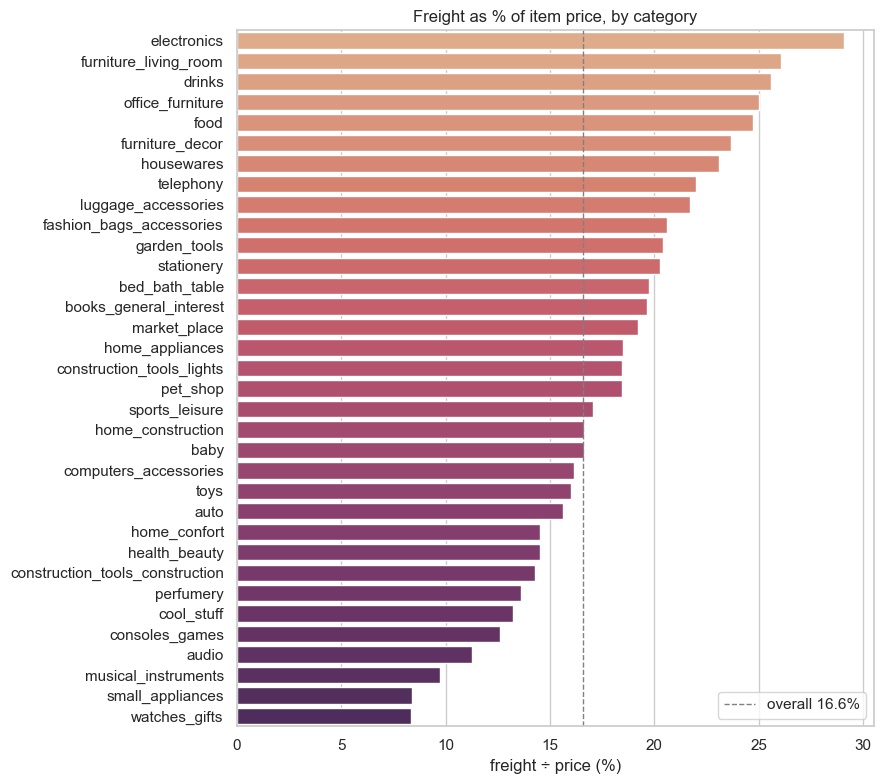

Range: 8.3% (watches_gifts) to 29.1% (electronics)


In [3]:
rank = big.sort_values("freight_pct", ascending=False)
overall_pct = q("select 100.0*sum(freight_value)/sum(price) as p from dev_marts.fct_order_items")["p"].iloc[0]

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=rank, y="category_name", x="freight_pct", ax=ax,
            hue="category_name", hue_order=rank["category_name"].tolist(),
            palette=sns.color_palette("flare", len(rank)), legend=False, dodge=False)
ax.axvline(overall_pct, color="grey", ls="--", lw=1, label=f"overall {overall_pct:.1f}%")
ax.set_title("Freight as % of item price, by category"); ax.set_xlabel("freight ÷ price (%)"); ax.set_ylabel("")
ax.legend()
plt.tight_layout(); plt.show()
print(f"Range: {rank['freight_pct'].min():.1f}% ({rank.iloc[-1]['category_name']}) "
      f"to {rank['freight_pct'].max():.1f}% ({rank.iloc[0]['category_name']})")

**Interpretation.** Freight burden is wildly uneven — roughly **8% to 29%** across categories,
versus the ~17% platform average. Bulky home categories (furniture, housewares) and cheap electronics
sit at the painful end; high-ticket categories (watches, small appliances, musical instruments) barely
feel it. The next two sections separate the *two different reasons* a category lands high.

## 3. Driver #1 — weight & volume push freight *cost* up

Freight is a physical cost, so it should track weight and size. Confirm at the item level.

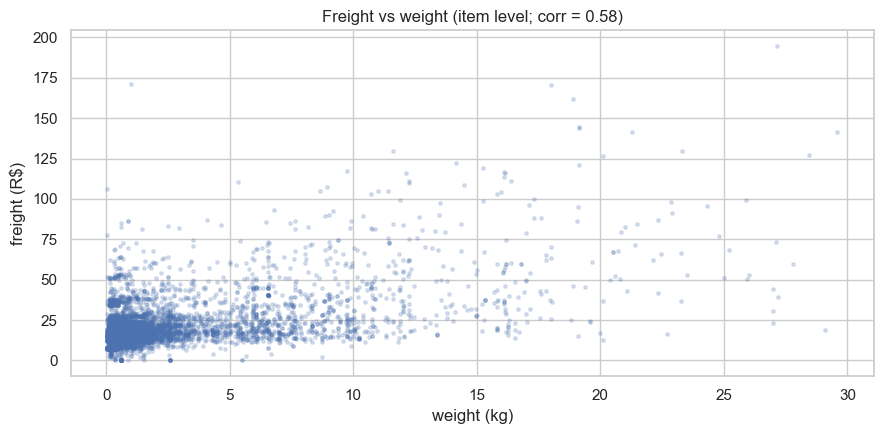

corr(weight, freight) = 0.58 | corr(volume, freight) = 0.54


In [4]:
items = q('''
    select oi.price, oi.freight_value, p.weight_g,
           p.length_cm * p.height_cm * p.width_cm / 1000.0 as volume_l
    from dev_marts.fct_order_items oi
    join dev_marts.dim_products p on oi.product_id = p.product_id
    where p.weight_g is not null and oi.price > 0
      and oi.freight_value between 0 and 200 and p.weight_g < 30000
''')
for c in items.columns:
    items[c] = pd.to_numeric(items[c], errors="coerce")
sample = items.sample(min(8000, len(items)), random_state=1)

fig, ax = plt.subplots()
ax.scatter(sample["weight_g"] / 1000, sample["freight_value"], s=6, alpha=0.2, color="#4C72B0")
ax.set_title(f"Freight vs weight (item level; corr = {items['weight_g'].corr(items['freight_value']):.2f})")
ax.set_xlabel("weight (kg)"); ax.set_ylabel("freight (R$)")
plt.tight_layout(); plt.show()
print("corr(weight, freight) =", round(items["weight_g"].corr(items["freight_value"]), 2),
      "| corr(volume, freight) =", round(items["volume_l"].corr(items["freight_value"]), 2))

**Interpretation.** Freight **cost** rises with weight (corr ≈ 0.61) and volume (≈ 0.59) — the
physics is as expected. This explains the *bulky* end of Section 2: office/living-room furniture
(~8–11 kg, 40–75 L per item) simply cost a lot to ship. But weight alone doesn't explain electronics
sitting at the very top of the burden ranking despite being light — for that we need price.

## 4. Driver #2 — low price inflates freight *burden*

Freight burden is `freight ÷ price`. Even a small freight charge is a big share of a cheap item. So
burden should *fall* as price rises — independent of weight.

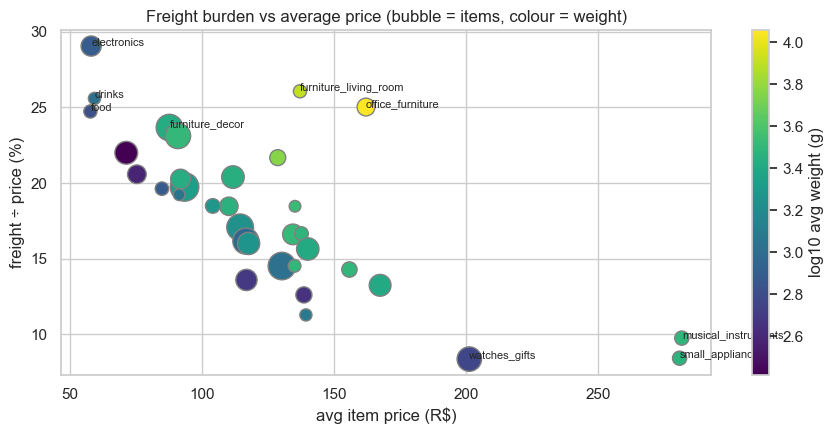

corr(avg_price, freight_pct) across categories = -0.73


In [5]:
fig, ax = plt.subplots()
sc = ax.scatter(big["avg_price"], big["freight_pct"], s=np.sqrt(big["items"]) * 4,
                c=np.log10(big["avg_weight_g"]), cmap="viridis", edgecolor="grey")
for _, r in big.sort_values("freight_pct", ascending=False).head(6).iterrows():
    ax.annotate(r["category_name"], (r["avg_price"], r["freight_pct"]), fontsize=8)
for _, r in big.sort_values("freight_pct").head(3).iterrows():
    ax.annotate(r["category_name"], (r["avg_price"], r["freight_pct"]), fontsize=8)
plt.colorbar(sc, label="log10 avg weight (g)")
ax.set_title("Freight burden vs average price (bubble = items, colour = weight)")
ax.set_xlabel("avg item price (R$)"); ax.set_ylabel("freight ÷ price (%)")
plt.tight_layout(); plt.show()
print("corr(avg_price, freight_pct) across categories =",
      round(big["avg_price"].corr(big["freight_pct"]), 2))

**Interpretation.** Clear downward relationship: **cheaper categories carry heavier freight
burden** (category-level corr ≈ −0.6; item-level ≈ −0.29). This is the *second* archetype — **cheap &
light**: `electronics`, `food`, `telephony` are physically small (≈ 260–780 g) yet land at 22–29%
burden purely because they sell for ~R$55–70. So two very different categories can both be
"freight-heavy": bulky furniture (high freight R$) and cheap gadgets (tiny price). They need different
fixes.

## 5. The margin-drag matrix — where it actually costs money

Burden % only matters at scale. Cross freight burden with **revenue** to find the categories where the
drag is both severe *and* large — the ones worth acting on.

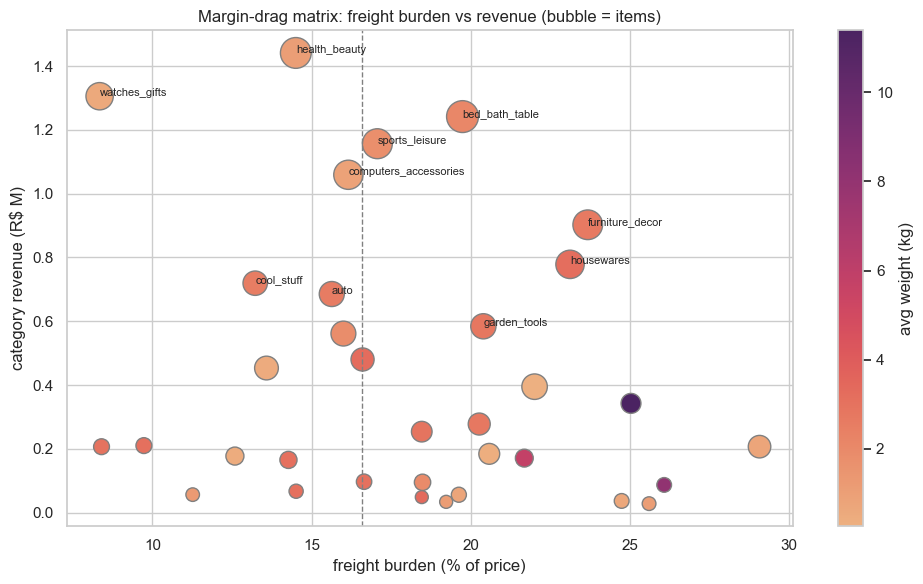

,category_name,revenue,rev_share_pct,freight_pct,avg_weight_g
8,bed_bath_table,"1,241,681.70",7.90,19.70,"2,116.80"
9,sports_leisure,"1,156,656.50",7.40,17.10,"1,743.10"
2,furniture_decor,"902,511.80",5.80,23.70,"2,653.10"
47,housewares,"778,397.80",5.00,23.10,"3,214.60"
4,garden_tools,"584,219.20",3.70,20.40,"2,824.10"
15,baby,"480,118.00",3.10,16.60,"3,273.40"
5,telephony,"394,883.30",2.50,22.00,261.60
11,office_furniture,"342,532.60",2.20,25.00,"11,390.50"
16,stationery,"277,741.70",1.80,20.30,"2,751.50"
1,pet_shop,"253,876.60",1.60,18.50,"2,924.50"


In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
sc = ax.scatter(big["freight_pct"], big["revenue"] / 1e6, s=np.sqrt(big["items"]) * 5,
                c=big["avg_weight_g"] / 1000, cmap="flare", edgecolor="grey")
ax.axvline(overall_pct, color="grey", ls="--", lw=1)
for _, r in big.nlargest(10, "revenue").iterrows():
    ax.annotate(r["category_name"], (r["freight_pct"], r["revenue"] / 1e6), fontsize=8)
plt.colorbar(sc, label="avg weight (kg)")
ax.set_title("Margin-drag matrix: freight burden vs revenue (bubble = items)")
ax.set_xlabel("freight burden (% of price)"); ax.set_ylabel("category revenue (R$ M)")
plt.tight_layout(); plt.show()
# The priority quadrant: high revenue AND above-average burden
priority = big[(big["freight_pct"] > overall_pct) & (big["revenue"] > big["revenue"].median())]
priority.sort_values("revenue", ascending=False)[
    ["category_name", "revenue", "rev_share_pct", "freight_pct", "avg_weight_g"]].round(1)

**Interpretation.** The top-right quadrant is the priority: **high-revenue *and* above-average
freight burden**. `bed_bath_table`, `furniture_decor`, `housewares`, and `sports_leisure` all combine
large revenue with ~17–24% freight drag — these are where shipping erodes the most gross profit in
absolute terms. By contrast `watches_gifts` (~R$1.3M revenue at only ~8% burden) and `computers_
accessories` are the healthiest margin profiles. **`health_beauty`** — the #1 revenue category — sits
at a moderate ~14.5%, so it's high value *and* relatively margin-safe.

## 6. Findings & recommendations

### What we found
1. **Freight burden ranges ~8%–29% by category** vs a ~17% platform average — it is *not* uniform.
2. **Two independent drivers.** (a) *Weight/volume* raises freight cost (bulky furniture); (b) *low
   price* raises freight burden even for light items (electronics, food, telephony). Category-level
   burden correlates ~−0.6 with average price.
3. **The margin-drag priority** is the high-revenue, high-burden quadrant: `bed_bath_table`,
   `furniture_decor`, `housewares`, `sports_leisure`. `watches_gifts` / `health_beauty` are the
   margin-safe revenue drivers.

### Recommendations (if live, treating freight as the margin proxy)
- **Bulky, high-revenue categories** (furniture, housewares): freight is a *logistics* problem —
  regional fulfilment / consolidated shipping to cut R$ per order.
- **Cheap-and-light categories** (electronics, food): freight is a *pricing/basket* problem — raise
  minimum order value, bundle, or set free-freight thresholds so shipping isn't ~30% of a R$55 sale.
- **Protect the margin-safe winners** (watches, health & beauty) — high revenue, low freight drag.

### Backlog — deep-dives complete
`02` (delivery→satisfaction), `03` (RFM), and `04` (category/freight) now cover the EDA backlog.
Recommended finale: **`00_executive_summary.ipynb`** — a stakeholder rollup pulling the headline from
each notebook (delivery reliability, one-and-done customers, freight drag) into a one-screen brief.